# 성능 최적화

## 하이퍼파라미터를 이용한 성능 최적화

### 드롭아웃을 이용한 성능 최적화

##### 라이브러리 호출

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

##### 데이터셋 내려받기

In [ ]:
trainset = torchvision.datasets.FashionMNIST(root='/', train=True,
                                             download=True,
                                             transform=transforms.ToTensor())

##### 데이터셋을 메모리로 가져오기

In [ ]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

##### 데이터셋 분리

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
9


##### 이미지 데이터를 출력하기 위한 전처리

In [ ]:
def imshow(img, title):
    plt.figure(figsize=(batch_size * 4, 4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.title(title)
    plt.show()

##### 이미지 데이터 출력 함수

In [ ]:
def show_batch_images(dataloader):
    images, labels = next(iter(dataloader))

    img = torchvision.utils.make_grid(images)
    imshow(img, title=[str(x.item()) for x in labels])

    return images, labels

##### 이미지 출력

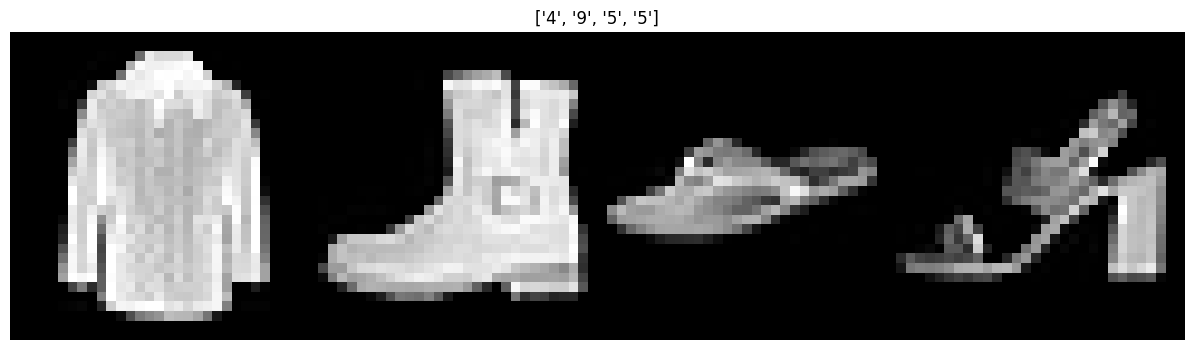

In [ ]:
iamges, labels = show_batch_images(trainloader)

##### 배치 정규화가 적용되지 않은 네트워크

In [ ]:
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

##### 배치 정규화가 포함된 네트워크

In [ ]:
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48),
            nn.BatchNorm1d(48),
            nn.ReLU(),
            nn.Linear(48, 24),
            nn.BatchNorm1d(24),
            nn.ReLU(),
            nn.Linear(24, 10)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

##### 배치 정규화가 적용되지 않은 모델 선언

In [ ]:
model = NormalNet().to(device)
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


##### 배치 정규화가 적용된 모델 선언

In [ ]:
model_bn = BNNet().to(device)
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


##### 데이터셋 메모리로 불러오기

In [ ]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

##### 옵티마이저, 손실 함수 지정

In [ ]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr=0.01)

##### 모델 학습

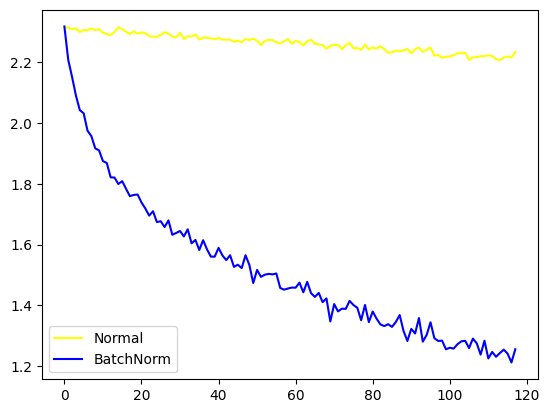

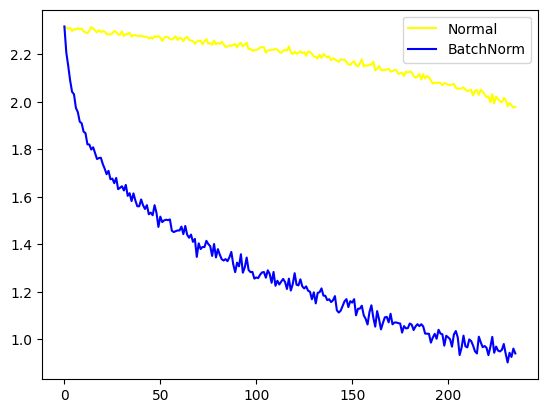

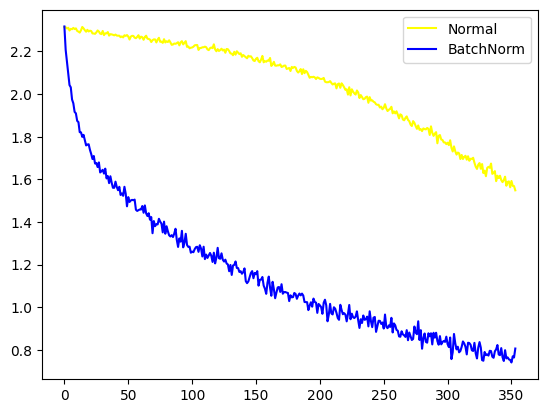

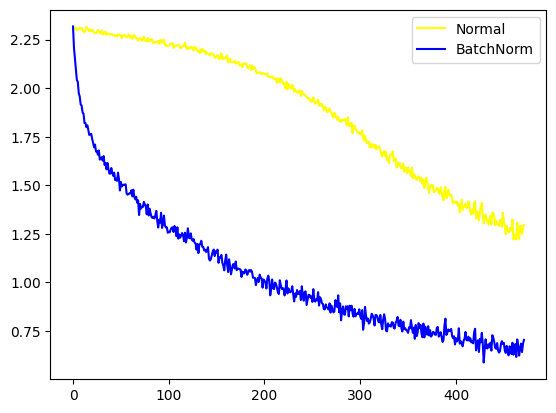

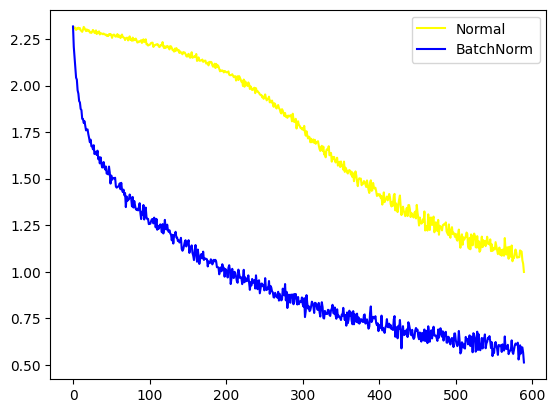

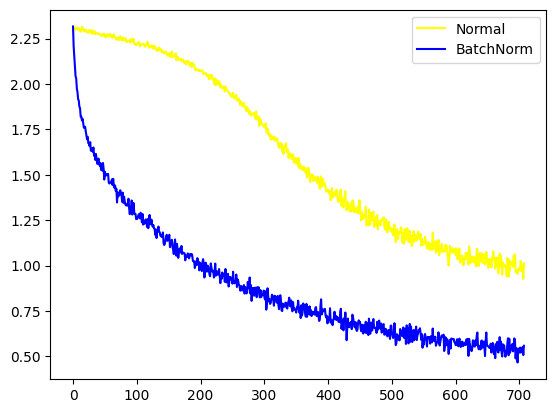

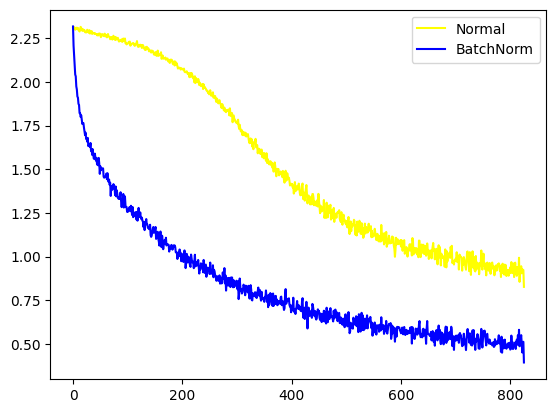

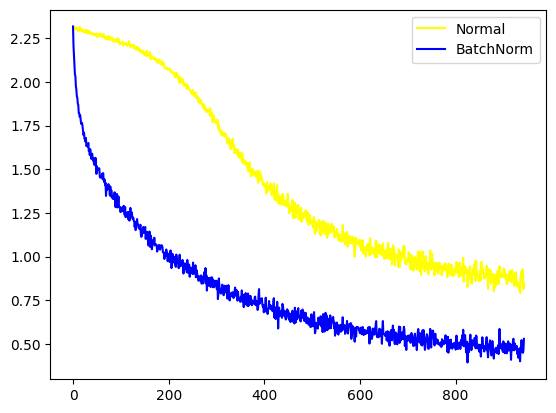

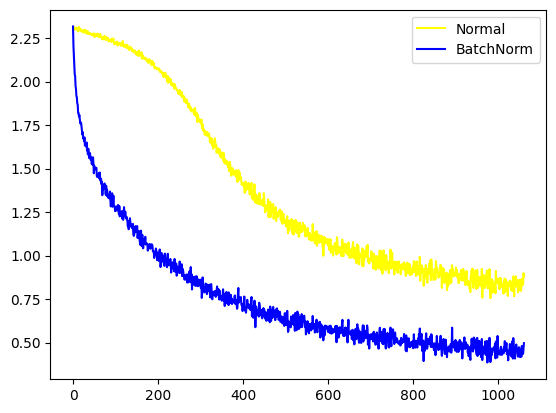

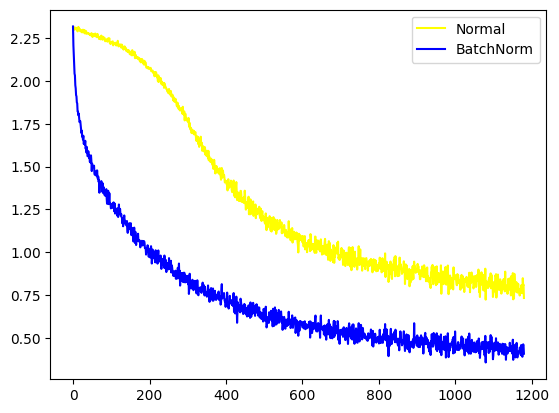

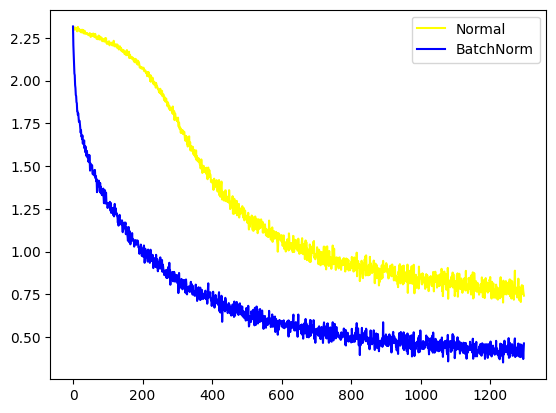

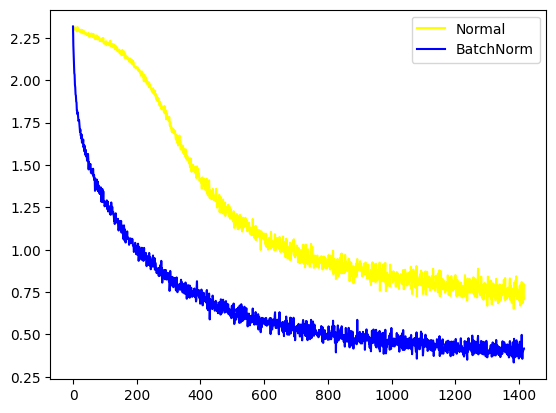

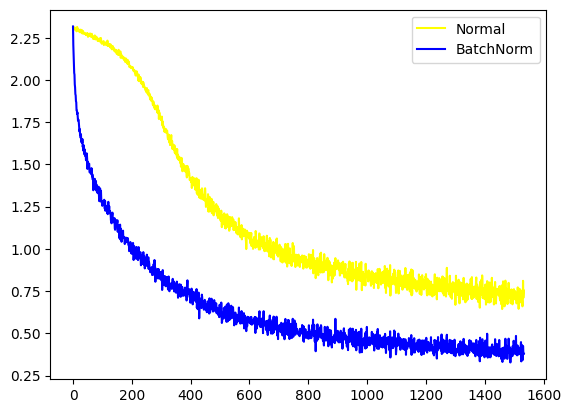

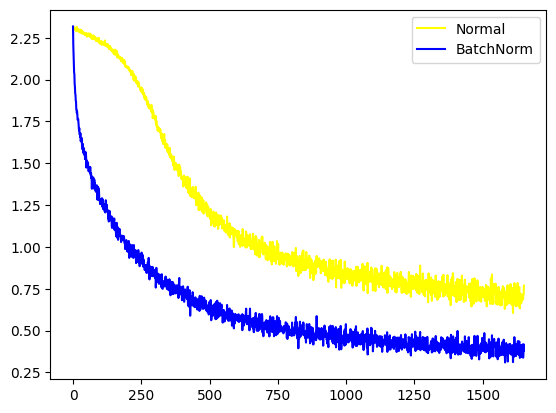

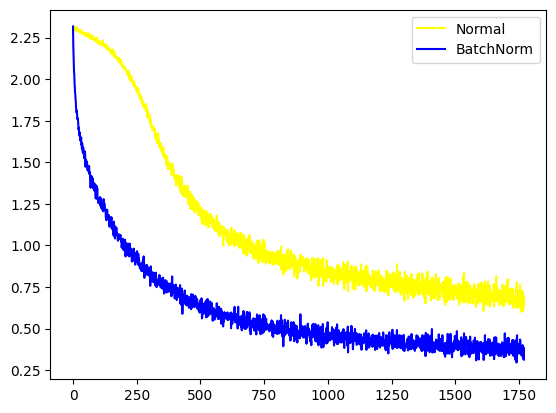

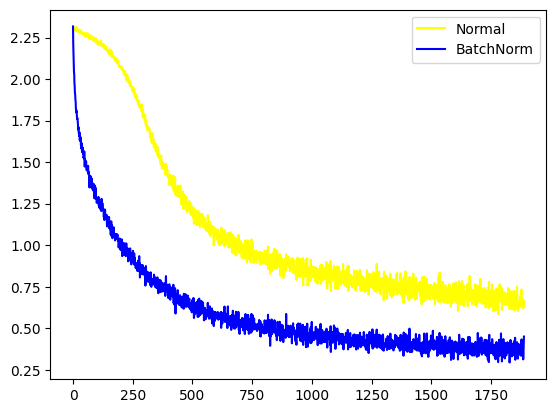

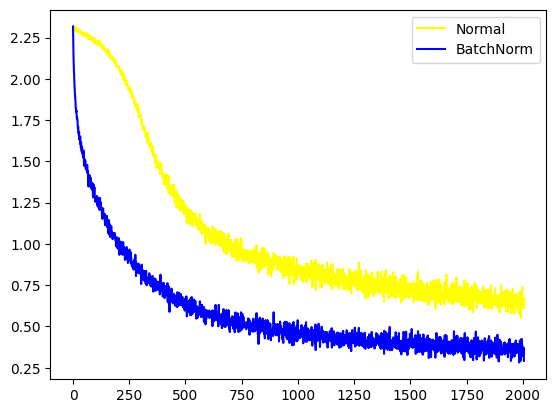

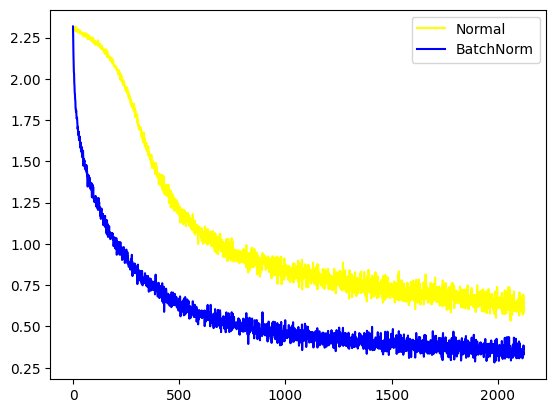

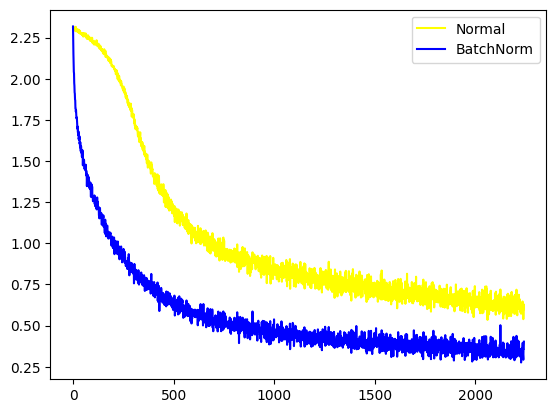

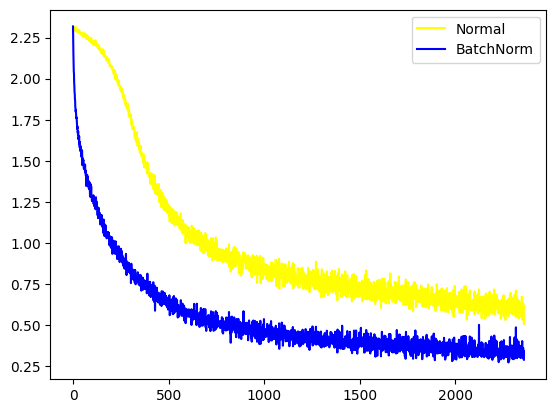

In [ ]:
loss_arr = []
loss_bn_arr = []
max_epochs = 20

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        opt.zero_grad()
        outputs = model(inputs).to(device)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        opt_bn.zero_grad()
        outputs_bn = model_bn(inputs).to(device)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

    plt.plot(loss_arr, 'yellow', label='Normal')
    plt.plot(loss_bn_arr, 'blue', label='BatchNorm')
    plt.legend()
    plt.show()

##### 데이터셋의 분포를 출력하기 위한 전처리

In [ ]:
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))
x_train, y_train= x_train.to(device), y_train.to(device)

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))
x_test, y_test = x_test.to(device), y_test.to(device)

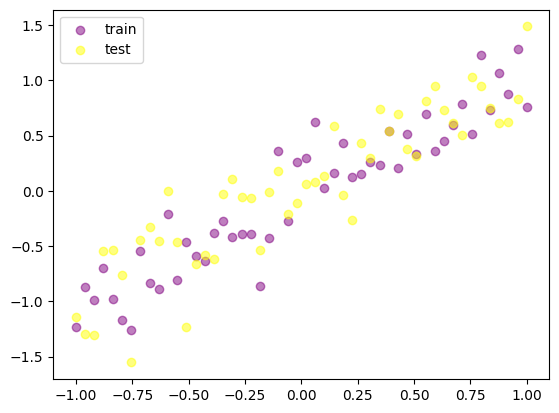

In [ ]:
plt.scatter(x_train.data.cpu().numpy(), y_train.data.cpu().numpy(), c='purple', alpha=0.5, label='train')
plt.scatter(x_test.data.cpu().numpy(), y_test.data.cpu().numpy(), c='yellow', alpha=0.5, label='test')
plt.legend()
plt.show()

##### 드롭아웃을 위한 모델 생성

In [ ]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
).to(device)

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, N_h),
    torch.nn.Dropout(0.2),
    torch.nn.ReLU(),
    torch.nn.Linear(N_h, 1),
).to(device)

##### 옵티마이저와 손실 함수 지정

In [ ]:
opt = torch.optim.Adam(model.parameters(), lr=0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr=0.01)
loss_fn = torch.nn.MSELoss().to(device)

##### 모델 학습

/tmp/ipykernel_708/3554529140.py:30: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.title('Epoch %d, Loss = %0.4f, Loss with dropout = %0.4f' % (epoch, test_loss, test_loss_dropout))


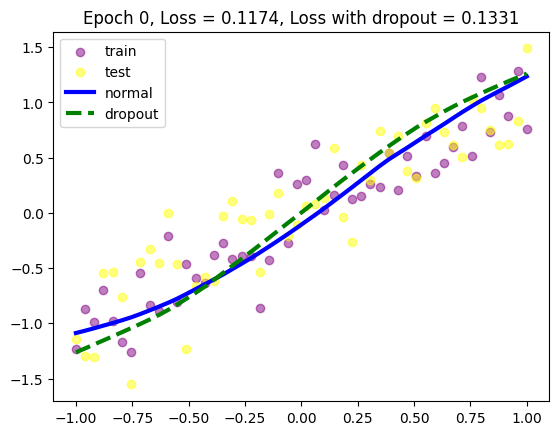

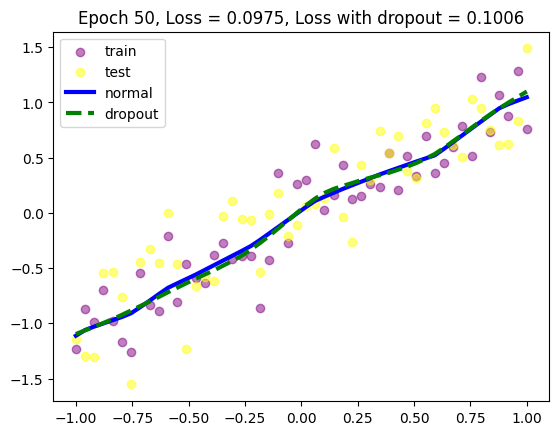

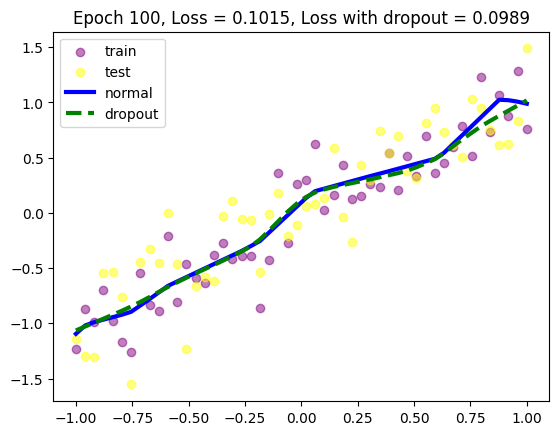

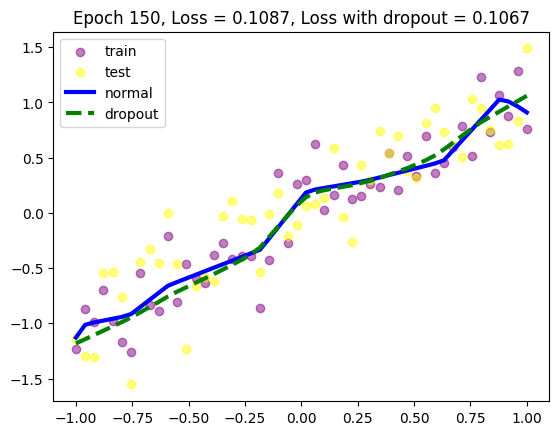

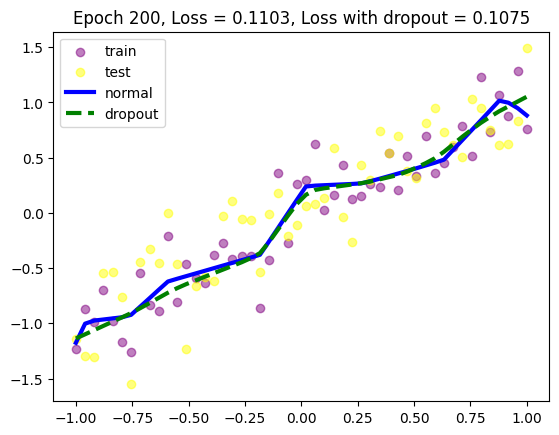

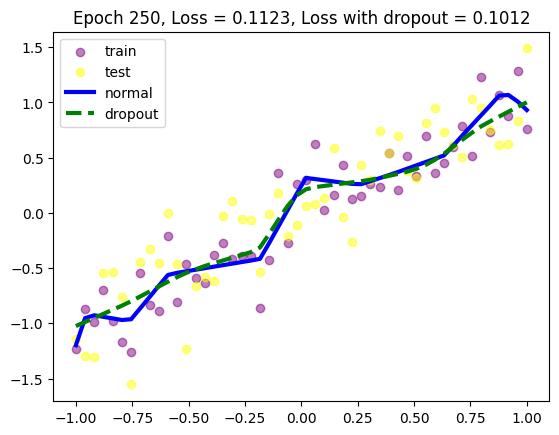

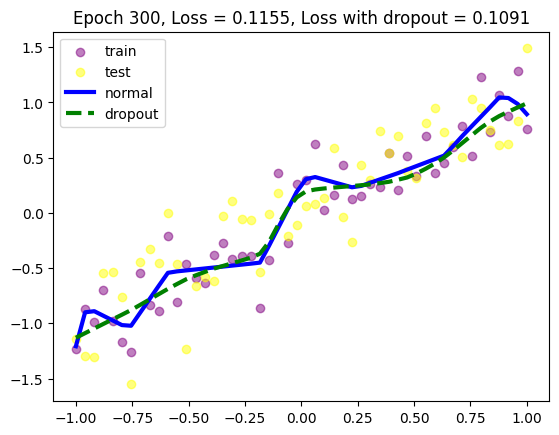

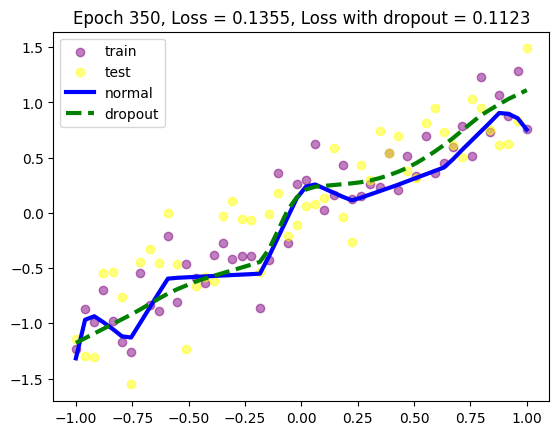

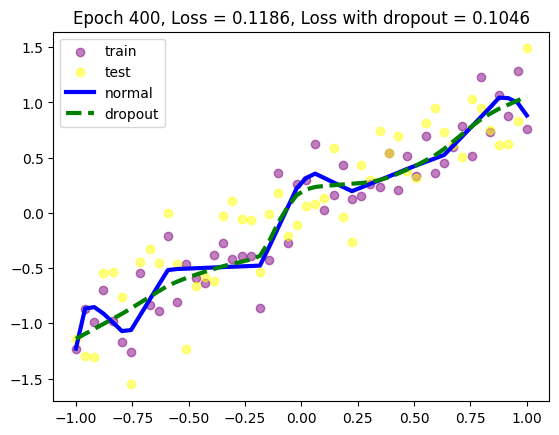

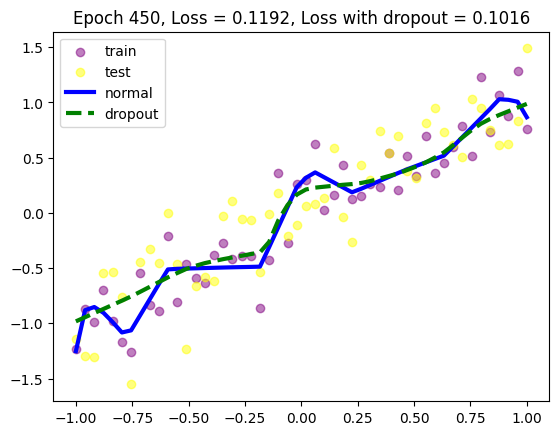

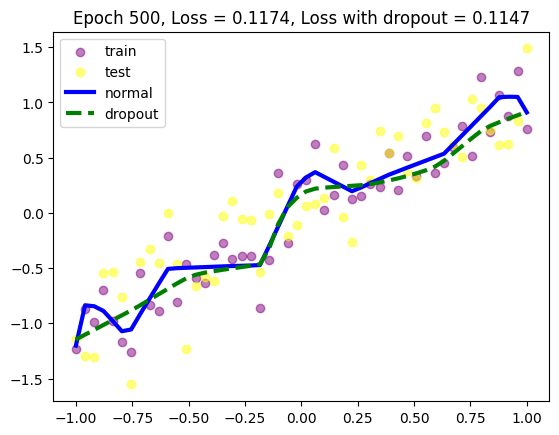

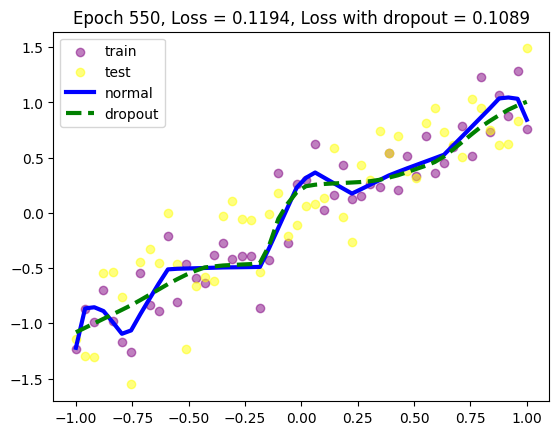

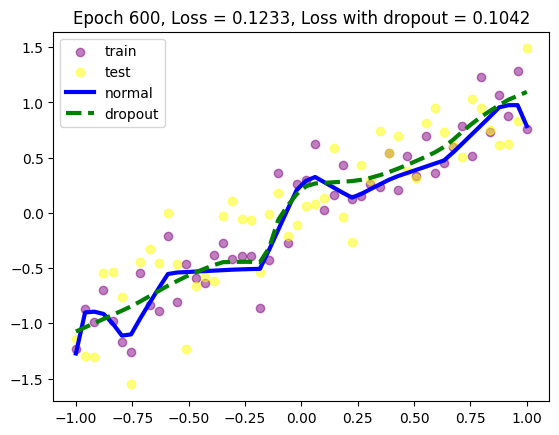

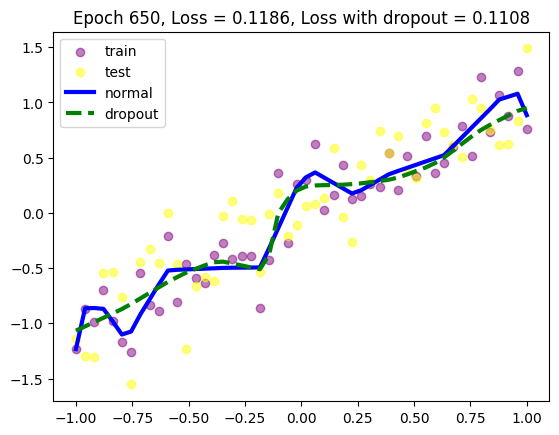

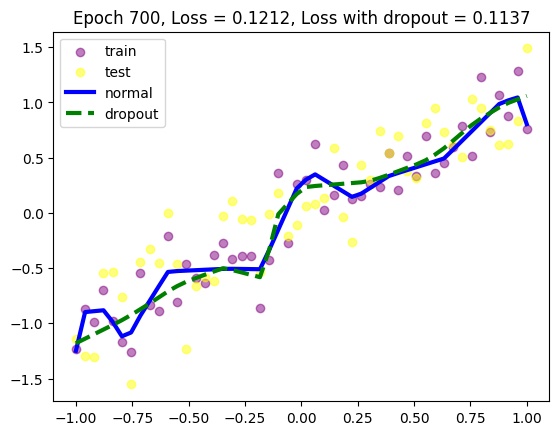

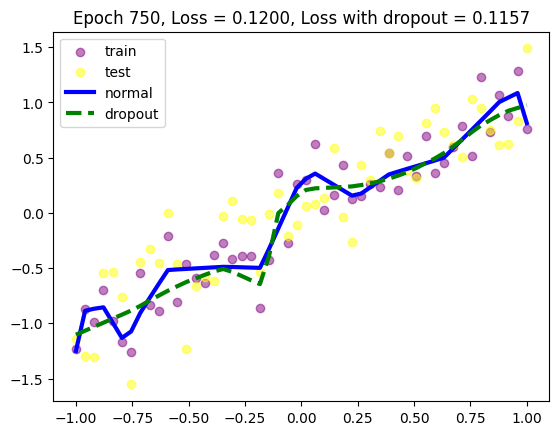

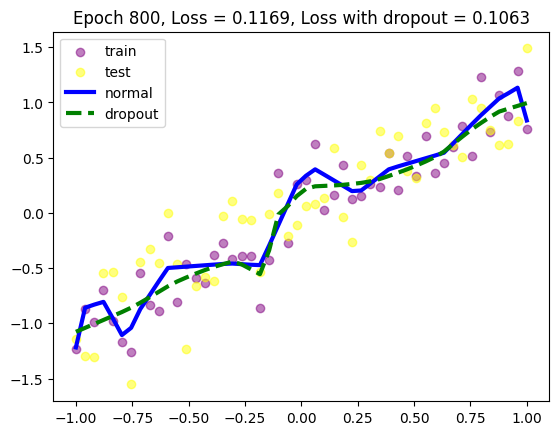

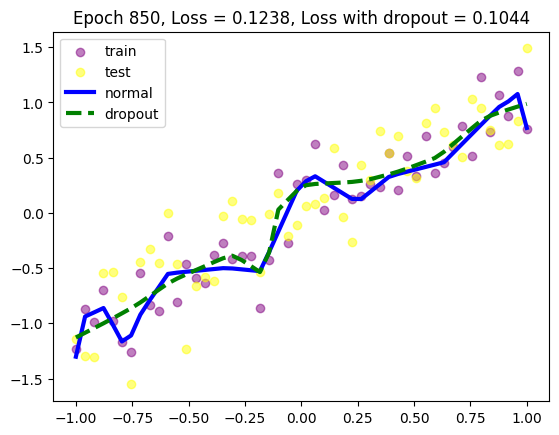

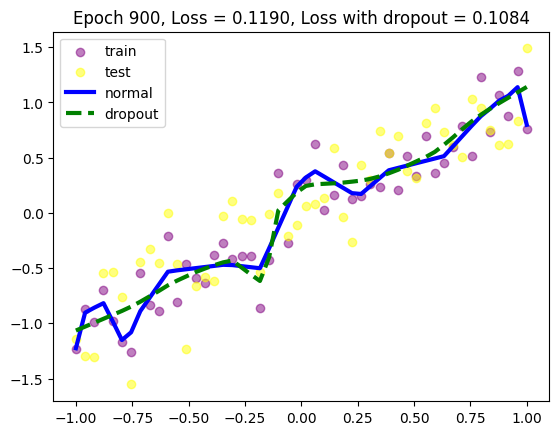

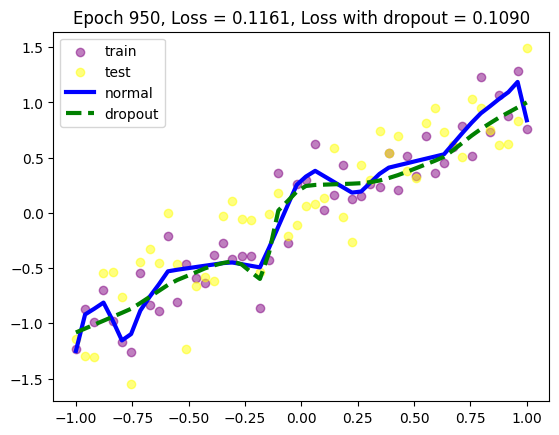

In [ ]:
max_epochs = 1000
for epoch in range(max_epochs):
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(x_train.data.cpu().numpy(), y_train.data.cpu().numpy(), c='purple', alpha=0.5, label='train')
        plt.scatter(x_test.data.cpu().numpy(), y_test.data.cpu().numpy(), c='yellow', alpha=0.5, label='test')
        plt.plot(x_test.data.cpu().numpy(), test_pred.data.cpu().numpy(), 'b-', lw=3, label='normal')
        plt.plot(x_test.data.cpu().numpy(), test_pred_dropout.data.cpu().numpy(), 'g--', lw=3,  label='dropout')

        plt.title('Epoch %d, Loss = %0.4f, Loss with dropout = %0.4f' % (epoch, test_loss, test_loss_dropout))
        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)

### 조기 종료를 이용한 성능 최적화

##### 라이브러리 호출

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision import transforms, datasets

import matplotlib
import matplotlib.pyplot as plt
import time

import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

##### 데이터셋 전처리

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

##### 데이터셋 가져오기

In [4]:
from google.colab import files # 데이터 불러오기
file_uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
!unzip archive.zip -d archive/

Archive:  archive.zip
   creating: archive/test/
   creating: archive/test/hot_dog/
  inflating: archive/test/hot_dog/133012.jpg  
  inflating: archive/test/hot_dog/133015.jpg  
  inflating: archive/test/hot_dog/133245.jpg  
  inflating: archive/test/hot_dog/135628.jpg  
  inflating: archive/test/hot_dog/138933.jpg  
  inflating: archive/test/hot_dog/138937.jpg  
  inflating: archive/test/hot_dog/138969.jpg  
  inflating: archive/test/hot_dog/139177.jpg  
  inflating: archive/test/hot_dog/142835.jpg  
  inflating: archive/test/hot_dog/143012.jpg  
  inflating: archive/test/hot_dog/144956.jpg  
  inflating: archive/test/hot_dog/146227.jpg  
  inflating: archive/test/hot_dog/146834.jpg  
  inflating: archive/test/hot_dog/147874.jpg  
  inflating: archive/test/hot_dog/152106.jpg  
  inflating: archive/test/hot_dog/154409.jpg  
  inflating: archive/test/hot_dog/154545.jpg  
  inflating: archive/test/hot_dog/156126.jpg  
  inflating: archive/test/hot_dog/156135.jpg  
  inflating: archive/te

In [29]:
train_dataset = datasets.ImageFolder(
    root='archive/train',
    transform=train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=32, shuffle=True
)
val_dataset = datasets.ImageFolder(
    root='archive/test',
    transform=val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=32, shuffle=False
)

##### 모델 생성

In [30]:
def resnet50(pretrained=True, requires_grad=False):
    model = models.resnet50(progress=True, pretrained=pretrained)
    if requires_grad:
        for param in model.parameters():
            param.requires_grad = True
    else:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Linear(2048, 2)
    return model

##### 학습률 감소

In [31]:
class LRScheduler():
    def __init__(self, optimizer, patience=5, min_lr=13-6, factor=0.5):
        self.optimizer = optimizer,
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            patience=self.patience,
            factor=self.factor,
            min_lr=self.min_lr,
            verbose=True
        )

    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)

##### 조기 종료

In [32]:
from google.colab import files # 데이터 불러오기
file_uploaded = files.upload()

In [33]:
class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0,
                 path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} -> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

##### 인수 값 지정

In [34]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest='lr_scheduler', action='store_true')
parser.add_argument('--early-stopping', dest='early_stopping', action='store_true')
args = vars(parser.parse_args([]))

##### 사전 훈련된 모델의 파라미터 확인

In [35]:
print(f'Computation device: {device}\n')
model = models.resnet50(pretrained=True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'{total_params:,} total parameters.')
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{total_trainable_params:,} training parameters.')

Computation device: cuda:0



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


25,557,032 total parameters.
25,557,032 training parameters.


##### 옵티마이저와 손실 함수 지정

In [36]:
lr = 0.001
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

##### 오차, 정확도 및 모델의 이름에 대한 문자열

In [37]:
loss_plot_name = 'loss'
acc_plot_name = 'accuracy'
model_name = 'model'

In [38]:
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler = LRScheduler(optimizer)
    loss_plot_name = 'lrs_loss'
    acc_plot_name = 'lrs_accuracy'
    model_name = 'lrs_model'
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping = EarlyStopping()
    loss_plot_name = 'es_loss'
    acc_plot_name = 'es_accuracy'
    model_name = 'es_model'

##### 모델 학습 함수

In [39]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(train_dataloader), total=int(len(train_dataset)/train_dataloader.batch_size))

    for i, data in prog_bar:
        counter += 1
        data, target = data[0].to(device), data[1].to(device)
        total += target.size(0)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        train_running_loss += loss.item()
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == target).sum().item()
        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100. * train_running_correct / total
    return train_loss, train_accuracy

##### 모델 검증 함수

In [40]:
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(test_dataloader), total=int(len(val_dataset)/test_dataloader.batch_size))

    with torch.no_grad():
        for i, data in prog_bar:
            counter += 1
            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)
            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

        val_loss = val_running_loss / counter
        val_accuracy = 100. * val_running_correct / total
        return val_loss, val_accuracy

##### 모델 학습

In [41]:
train_loss, train_accuracy = [], []
val_loss, val_accuracy = [], []

start = time.time()
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    train_epoch_loss, train_epoch_accuracy = training(model, train_dataloader, train_dataset, optimizer, criterion)
    val_epoch_loss, val_epoch_accuracy = validate(model, val_dataloader, val_dataset, criterion)

    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)

    if args['lr_scheduler']:
        lr_scheduler(val_epoch_loss)
    if args['early_stopping']:
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

    print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
    print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")
end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")

Epoch 1 of 100
Training


16it [00:04,  3.20it/s]


Validating


16it [00:03,  4.65it/s]


Train Loss: 2.5178, Train Acc: 56.83
Val Loss: 55.8825, Val Acc: 49.60
Epoch 2 of 100
Training


...

Train Loss: 0.0491, Train Acc: 98.59
Val Loss: 1.5646, Val Acc: 73.60
Epoch 100 of 100
Training


16it [00:05,  3.19it/s]


Validating


16it [00:03,  4.15it/s]

Train Loss: 0.0551, Train Acc: 97.59
Val Loss: 2.6572, Val Acc: 63.40
Training time: 14.621 minutes


##### 모델 학습 결과 출력

Saving loss and accuracy plots...


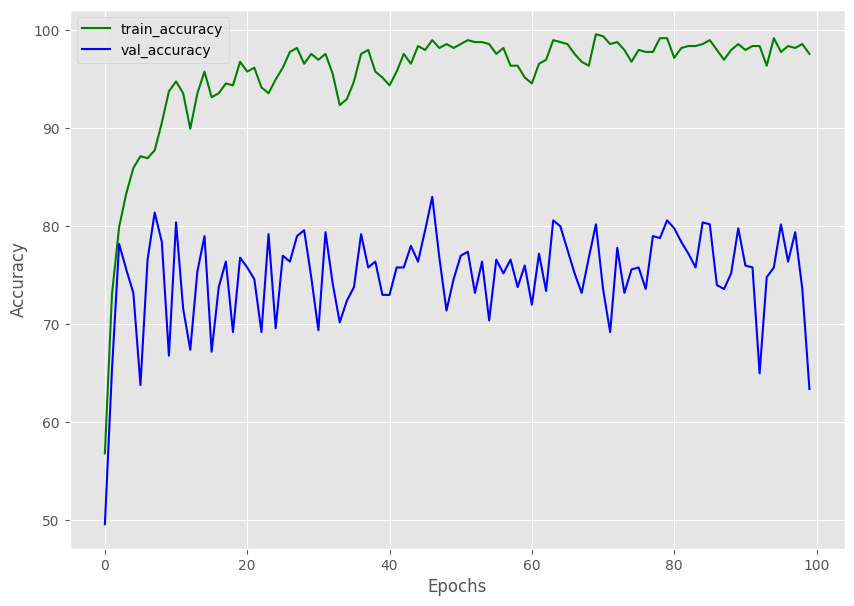

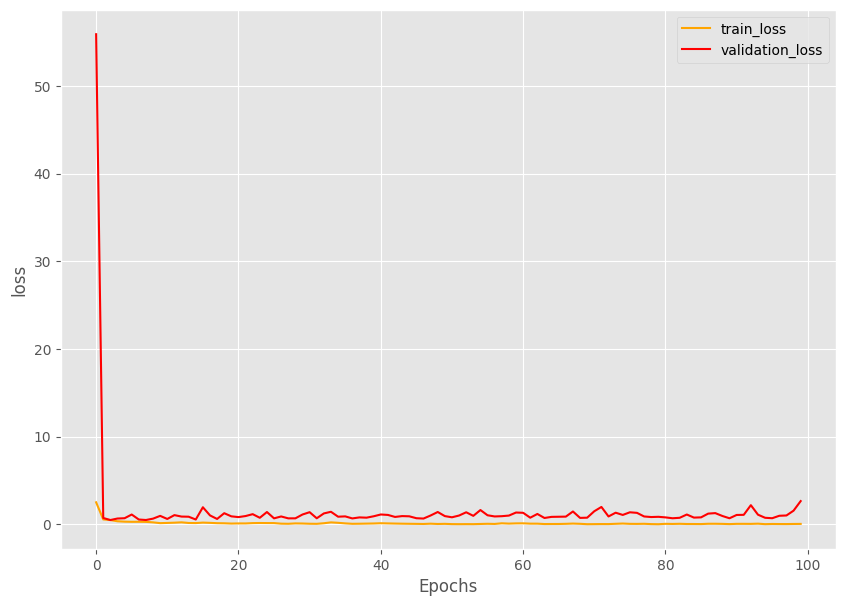

Saving model...
TRAINING COMPLETE!


In [42]:
print('Saving loss and accuracy plots...')
plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train_accuracy')
plt.plot(val_accuracy, color='blue', label='val_accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f'{acc_plot_name}.png')
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train_loss')
plt.plot(val_loss, color='red', label='validation_loss')

plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()
plt.savefig(f'{loss_plot_name}.png')
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f'{model_name}.pth')
print('TRAINING COMPLETE!')